In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches
import xeofs as xo
import cartopy

from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from region import Region
pfns = PlottingFns()

In [16]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

In [37]:
sla0 = SLA(deg=0.25).da
sla1 = SLA(deg=1).da

In [5]:
p = sla0.polyfit(dim='time',deg=1)

/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


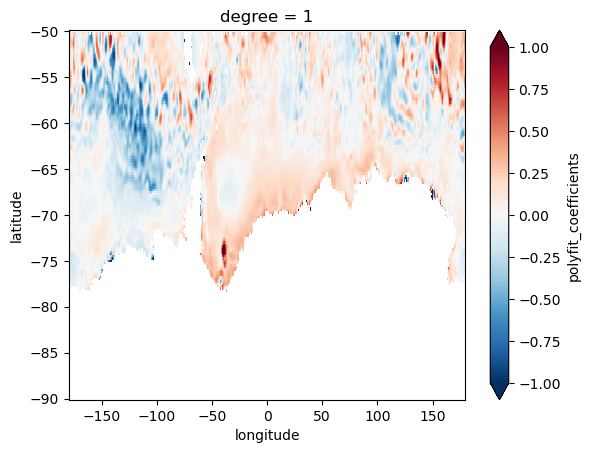

In [6]:
(p.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24 * 365.25).plot(vmax=1) 

In [7]:
ext3 = [120,160,-68.5,-65]
ext3r = Region('EA shelf',ext3,elevation=GEBCO(coarsen_factor=40).ds.elevation,min_elevation=-1000)

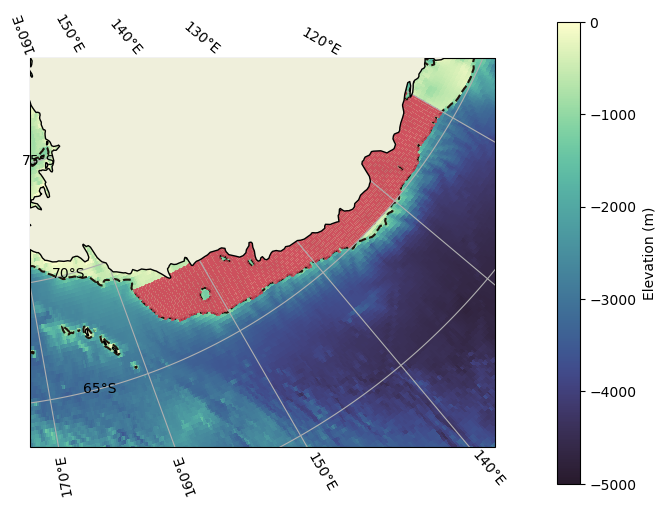

In [8]:
ext3r.plot_region(extent=[120,170,-70,-63])
crop = lambda sla, ext: sla.sel(latitude=slice(ext[2],ext[3])).sel(longitude=slice(ext[0],ext[1]))

/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


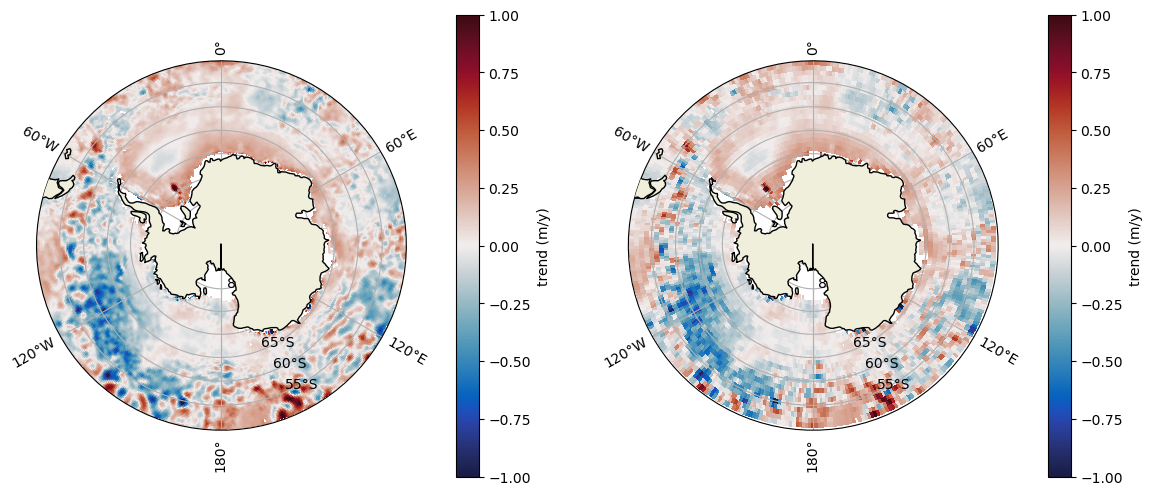

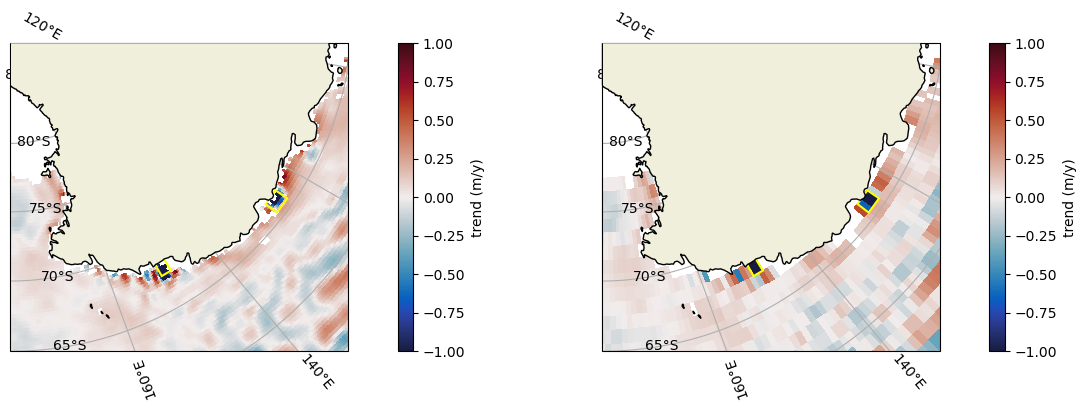

In [9]:
fig,ax = plt.subplots(1,2,figsize=(14,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],get_trend(sla0),vmax=1,cbar='trend (m/y)',cmap=cmocean.cm.balance,cbar_orientation='vertical')
pfns.sp(ax[1],get_trend(sla1),vmax=1,cbar='trend (m/y)',cmap=cmocean.cm.balance,cbar_orientation='vertical')

fig,ax = plt.subplots(1,2,figsize=(14,4),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],get_trend(sla0),vmax=1,cbar='trend (m/y)',cmap=cmocean.cm.balance,cbar_orientation='vertical',extent=[100,180,-75,-65])
pfns.sp(ax[1],get_trend(sla1),vmax=1,cbar='trend (m/y)',cmap=cmocean.cm.balance,cbar_orientation='vertical',extent=[100,180,-75,-65])

def patch(ax,ext,ec='yellow'):
    ax.add_patch(mpatches.Rectangle(xy=[ext[0], ext[2]],
                                width=ext[1]-ext[0],
                                height=ext[3]-ext[2],
                                facecolor='none', edgecolor=ec,
                                linewidth=1.5,
                                transform=ccrs.PlateCarree()))
ext1 = [148.5,150.5,-68.5,-67.5]
ext2 = [124.5,127.5,-66.5,-65.5]

patch(ax[0],ext1)
patch(ax[0],ext2)
patch(ax[1],ext1)
patch(ax[1],ext2)
# patch(ax[0],ext3,ec='mediumspringgreen')
# patch(ax[1],ext3,ec='mediumspringgreen')

# plot 3rd area
elev = crop(GEBCO(coarsen_factor=40).ds.elevation,ext3)
ax[0].contour(elev,levels=[-1000],transform=ccrs.PlateCarree())


In [11]:
sla0_1 = crop(sla0,ext1)
sla0_2 = crop(sla0,ext2)
sla1_1 = crop(sla1,ext1)
sla1_2 = crop(sla1,ext2)
sla0_3 = crop(sla0,ext3)
sla1_3 = crop(sla1,ext3)

In [12]:
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
sic1 = crop(sice,ext1)
sic2 = crop(sice,ext2)
sic3 = crop(sice,ext3)

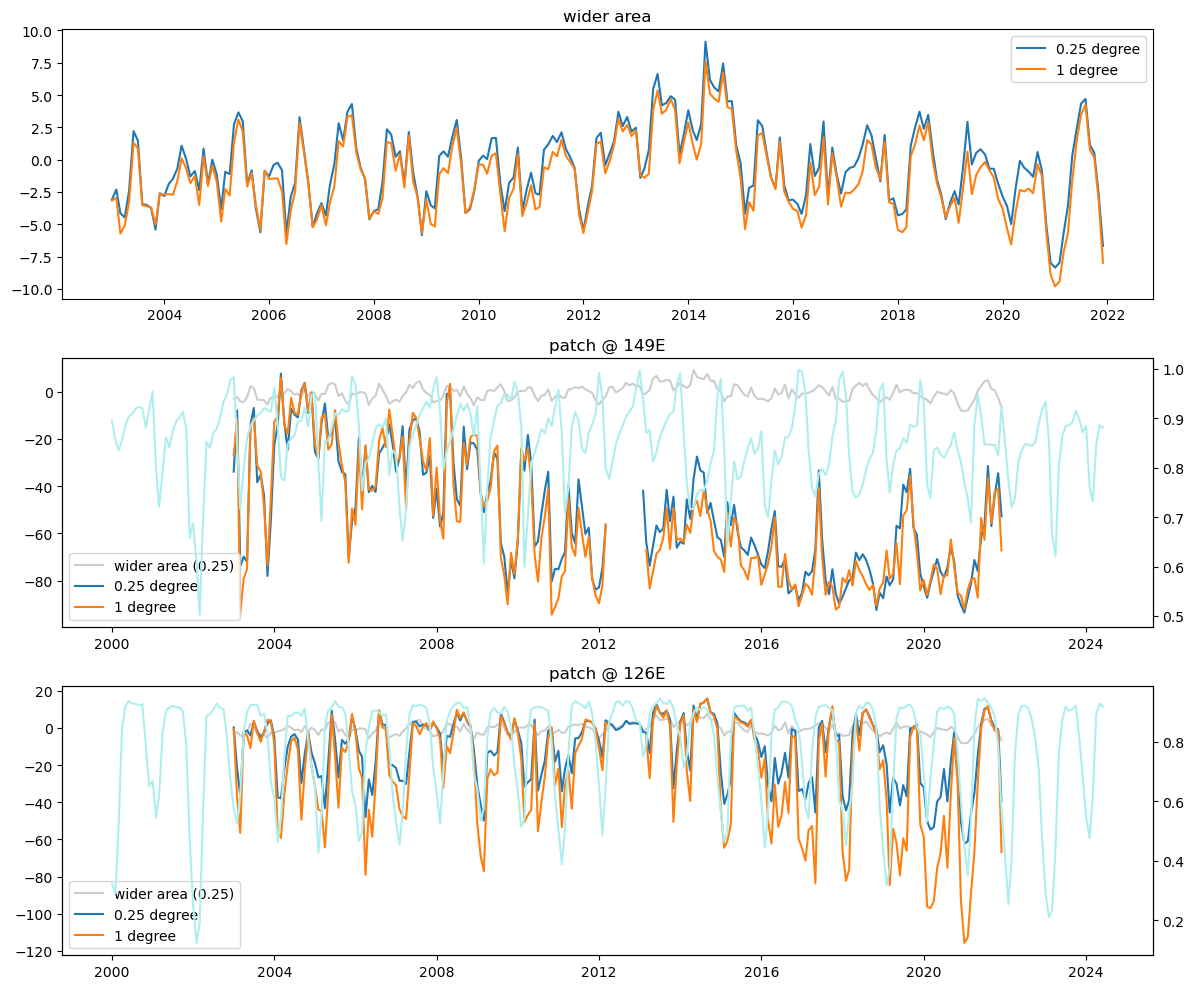

In [13]:
fig,ax = plt.subplots(3,1,figsize=(12,10))

ax[1].plot(sla0_3.time,sla0_3.mean(['latitude','longitude']),label='wider area (0.25)',c='0.8')
ax[2].plot(sla0_3.time,sla0_3.mean(['latitude','longitude']),label='wider area (0.25)',c='0.8')

ax[1].plot(sla0_1.time,sla0_1.mean(['latitude','longitude']),label='0.25 degree')
ax[0].plot(sla0_3.time,sla0_3.mean(['latitude','longitude']),label='0.25 degree')
ax[2].plot(sla0_2.time,sla0_2.mean(['latitude','longitude']),label='0.25 degree')

ax[1].plot(sla1_1.time,sla1_1.mean(['latitude','longitude']),label='1 degree')
ax[2].plot(sla1_2.time,sla1_2.mean(['latitude','longitude']),label='1 degree')
ax[0].plot(sla1_3.time,sla1_3.mean(['latitude','longitude']),label='1 degree')

#add sea ice
#ax[0].twinx().plot(sic1.time,sic1.mean(['latitude','longitude']),c='paleturquoise',label='sea ice concentration')
ax[1].twinx().plot(sic2.time,sic2.mean(['latitude','longitude']),c='paleturquoise',label='sea ice concentration')
ax[2].twinx().plot(sic3.time,sic3.mean(['latitude','longitude']),c='paleturquoise',label='sea ice concentration')

ax[0].set_title('wider area')
ax[0].legend()
ax[1].set_title('patch @ 149E')
ax[1].legend()
ax[2].set_title('patch @ 126E')
ax[2].legend()

plt.tight_layout()


Text(0.5, 1.0, 'sea ice concentration')

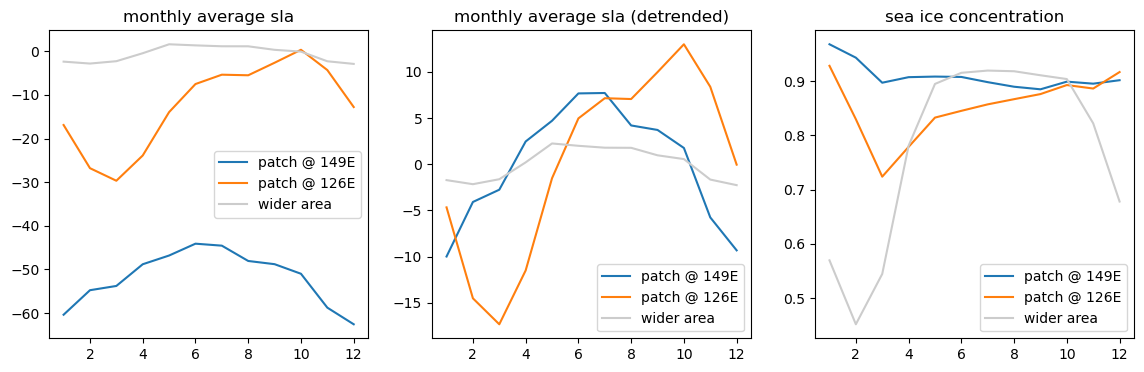

In [14]:
fig,axs = plt.subplots(1,3,figsize=(14,4))
sla0_1_c = sla0_1.groupby('time.month').mean()
sla0_2_c = sla0_2.groupby('time.month').mean()
sla0_3_c = sla0_3.groupby('time.month').mean()

axs[0].plot(sla0_1_c.month,sla0_1_c.mean(['latitude','longitude']),label='patch @ 149E')
axs[0].plot(sla0_2_c.month,sla0_2_c.mean(['latitude','longitude']),label='patch @ 126E')
axs[0].plot(sla0_3_c.month,sla0_3_c.mean(['latitude','longitude']),label='wider area',c='0.8')
axs[0].legend()
axs[0].set_title('monthly average sla')

sla0_1_c = utls.detrend_dim(sla0_1,'time').groupby('time.month').mean()
sla0_2_c = utls.detrend_dim(sla0_2,'time').groupby('time.month').mean()
sla0_3_c = utls.detrend_dim(sla0_3,'time').groupby('time.month').mean()

axs[1].plot(sla0_1_c.month,sla0_1_c.mean(['latitude','longitude']),label='patch @ 149E')
axs[1].plot(sla0_2_c.month,sla0_2_c.mean(['latitude','longitude']),label='patch @ 126E')
axs[1].plot(sla0_3_c.month,sla0_3_c.mean(['latitude','longitude']),label='wider area',c='0.8')
axs[1].legend()
axs[1].set_title('monthly average sla (detrended)')

axs[2].plot(sla0_1_c.month,sic1.groupby('time.month').mean().mean(['latitude','longitude']),label='patch @ 149E')
axs[2].plot(sla0_1_c.month,sic2.groupby('time.month').mean().mean(['latitude','longitude']),label='patch @ 126E')
axs[2].plot(sla0_1_c.month,sic3.groupby('time.month').mean().mean(['latitude','longitude']),label='wider area',c='0.8')
axs[2].legend()
axs[2].set_title('sea ice concentration')

In [38]:

extent_mi = [20,180,-74,-50]
sla0 = crop_to_extent(sla0,extent_mi)#.rolling({'latitude':4,'longitude':4},center=True).mean()
sla_detrend =  utls.detrend_dim(sla0,'time')
sla_anomaly = sla_detrend.groupby('time.month') - sla_detrend.groupby('time.month').mean()

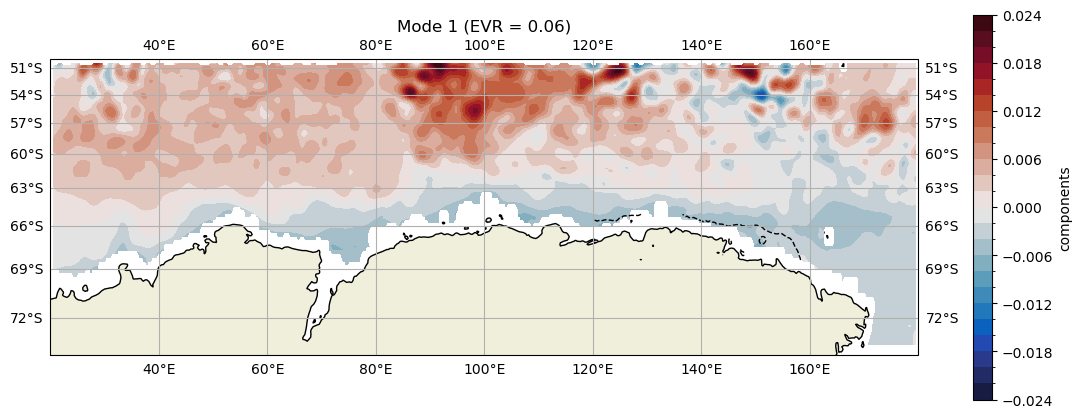

In [31]:
model = xo.single.EOF(n_modes=1,use_coslat=True,center=True)
model.fit(sla_anomaly.interpolate_na(dim='time'), dim="time")

evr = model.explained_variance_ratio()

components = model.components() # eofs, [mode, lat, lon]

fig, ax = plt.subplots(figsize=(14,5),subplot_kw={'projection':ccrs.Mercator()})


components.sel(mode=1).plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=25)
elev.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

ax.set_title('Mode {} (EVR = {})'.format(1,round(evr.item(),2)))
ax.set_extent(extent_mi,crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='k')
ax.gridlines(draw_labels=True)


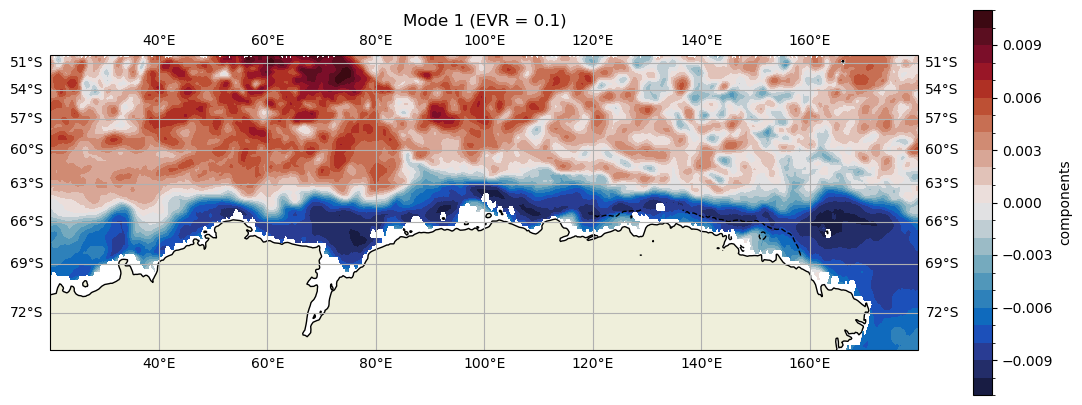

In [39]:
model = xo.single.EOF(n_modes=1,standardize=True,use_coslat=True)
model.fit(sla_anomaly.interpolate_na(dim='time'), dim="time")

evr = model.explained_variance_ratio()

components = model.components() # eofs, [mode, lat, lon]

fig, ax = plt.subplots(figsize=(14,5),subplot_kw={'projection':ccrs.Mercator()})


components.sel(mode=1).plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=25)
elev.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

ax.set_title('Mode {} (EVR = {})'.format(1,round(evr.item(),2)))
ax.set_extent(extent_mi,crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='k')
ax.gridlines(draw_labels=True)


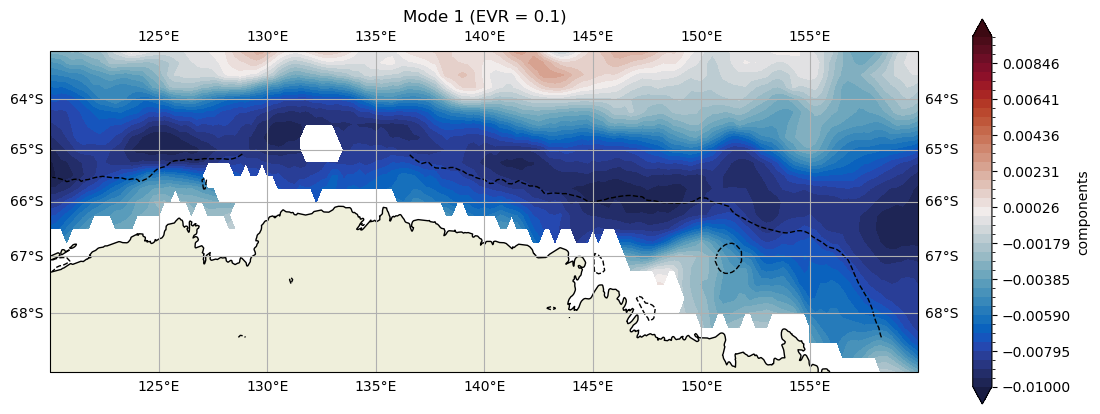

In [41]:
fig, ax = plt.subplots(figsize=(14,5),subplot_kw={'projection':ccrs.Mercator()})


components.sel(mode=1).plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40,vmin=-0.01,vmax=0.01)
elev.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

ax.set_title('Mode {} (EVR = {})'.format(1,round(evr.item(),2)))
ax.set_extent([120,160,-69,-63],crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='k')
ax.gridlines(draw_labels=True)